# **🏦 Predictive Marketing: Term Deposit Conversion**


**Team Members:** BERNARD Tao & ROUMIEUX Emile  
**Date:** June 3, 2026

# **1. Research Goal**


We aim to predict whether a banking client will subscribe to a term deposit during a telemarketing campaign, and to identify which variables are most important for this prediction.

## **2. Dataset Description**


Our project uses the popular **"Bank Marketing" dataset from Kaggle**

* **Source of the data:** Kaggle (Bank Marketing Dataset).
* **Number of observations:** 11,162 unique client contacts (rows).
* **Number and types of variables:** 16 predictor variables, containing a mix of numerical data (such as `age`, `balance`, `duration`, and `campaign`) and categorical data (such as `job`, `marital status`, and `education`).
* **Response variable:** `deposit` (Binary target: 'yes' if the client subscribed, 'no' if they refused).
* **Main features:** The most important predictors used in our final models are `duration` (the length of the phone call), `balance` (the client's yearly bank balance), `campaign` (number of contacts made during this campaign), and `poutcome` (the success or failure of past marketing campaigns).
* **Data quality issues:**
    * *Class Balance:* The dataset is highly balanced (~52% 'no' and ~48% 'yes'), meaning we do not have to deal with class imbalance issues.
    * *Outliers:* The `balance` variable contained very extreme values. We fixed this by applying soft-clipping at the 99th percentile to keep extreme values from distorting our predictions. No missing values (NaNs) were present in the data.

**For every coding parts, look up to the ANNEXE Section at the end of the report**

# **3. Data Processing and Exploratory Analysis**

Our bank marketing dataset contains 11,162 observations well balanced between positive and negative outcomes: 5,873 negative (no, 52.6%) and 5,289 positive (yes, 47.4%) instances.

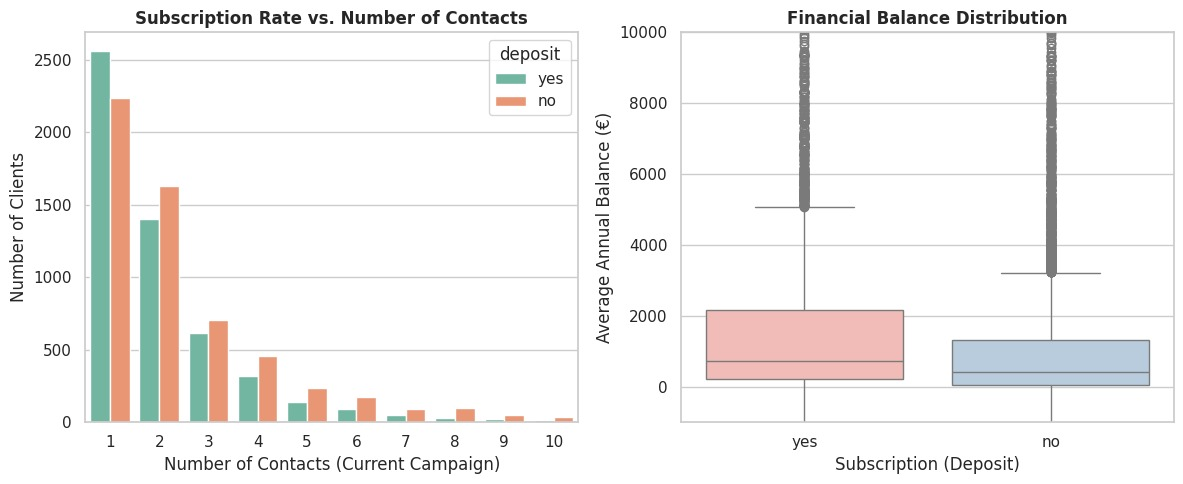

Visual analysis reveals two key insights:

1. Marketing Fatigue: Subscription rates decay significantly after 3 to 4 contact attempts.

2. Financial Profile: Clients who subscribe generally have a higher annual balance.


To prepare the data for the logistic and linear models, we applied this :


We removed non-predictive variables (day, pdays, previous) to reduce noise.

We capped the extreme values of the balance variable at the 99th percentile (soft-clipping) to prevent them from distorting the models.



Then we continue preprocessing by randomly splitting our main dataset in two parts : training set and testing set. We choose to  keep 30% of the data aside to test if the model can accurately predict outcomes for new, unseen clients.
We lock the randomness to ensure the code produces the exact same results every time we run it.

We also convert text data (like job titles or marital status) into numbers (1s and 0s) because the machine learning model can only understand mathematics. (One-Hot Encoding)

Finally, we align the training and testing datasets to make sure they have the exact same columns, which prevents the code from crashing if a category is missing.


# **4. Method Details**

## **A. Logistic Regression**

Our main objective is to predict wether the campaign is going to be useful or no (i.e. the clients will invest or no).
We are working on a qualitative variable with a binary outcome, therefore baseline model we can use for the prediction of this type of variable is logistic regression, because as we said earlier a dummy model predicting only one outcome would be wrong around 50%of the time, making it pretty useless. We will first implement this logistic regression model and then analyse the outcome with several criterias indicating its performance.



Now that categorical variables are encoded, we will scale the quantitative (numerical) variables. Scaling helps to bring all features to a similar range, which can improve the performance and convergence of many machine learning algorithms, including Logistic Regression.

With both categorical and numerical features preprocessed, we can now retrain and evaluate the Logistic Regression model using the scaled data.

### Analysis of Logistic Regression Results





The logistic regression model achieved an accuracy of **81.9%** on the test set. This means that approximately 82% of the predictions made by the model were correct. Let's delve into the `Classification Report` to understand the performance in more detail for each class ('no' and 'yes' for deposit).

*   **Precision**: For the 'no' class, the precision is 0.83, meaning that when the model predicts 'no', it is correct 83% of the time. For the 'yes' class, the precision is 0.83, meaning that when the model predicts 'yes', it is correct 83% of the time.
*   **Recall**: For the 'no' class, the recall is 0.85, indicating that the model correctly identified 85% of all actual 'no' cases. For the 'yes' class, the recall is 0.80, meaning it correctly identified 80% of all actual 'yes' cases.
*   **F1-score**: This is the harmonic mean of precision and recall. An F1-score of 0.84 for 'no' and 0.82 for 'yes' indicates a good balance between precision and recall for both classes.
*   **Support**: This is the number of actual occurrences of the class in the specified dataset. There are 1774 'no' cases and 1575 'yes' cases in the test set.

Overall, the model shows good performance with relatively balanced precision and recall for both classes. The slight difference in recall suggests the model is slightly better at identifying clients who will *not* make a deposit compared to those who *will*.



Furthermore, to understand which factors the logistic regression model considers important, we can look at the coefficients. The sign of the coefficient indicates the direction of the relationship (positive means it increases the likelihood of a 'yes' deposit, negative means it decreases it), and the magnitude indicates the strength of that relationship (larger absolute value means stronger influence).

By examining these coefficients, you can identify the features that had the strongest positive and negative impacts on the probability of a client making a deposit in this specific logistic regression model. For instance:

*   Features with large **positive coefficients** significantly increase the likelihood of a 'yes' deposit : poutcomesuccess.
*   Features with large **negative coefficients** significantly decrease the likelihood of a 'yes' deposit : contactunknown.
*   Features with coefficients close to zero have less influence on the prediction : age / day.

We want to have a fair comparison, so we will keep the same training and testing subsets for the following modeling parts.

## **B. LASSO Regularization**

We chose LASSO to address the risk of overfitting. Unlike standard regression, LASSO imposes an $L_1$ penalty, effectively performing automated feature selection.

By applying an $L_1$ penalty to the cost function, the LASSO model forces the coefficients of less predictive or highly collinear features to zero.

 This results in a "sparse" model, which is easier to interpret and less prone to overfitting than a standard logistic regression.

We used a Grid Search with 5-fold Cross-Validation to find the optimal regularization strength (C = 166.8101), achieving a stable test accuracy of 81.99% while automatically removing noisy features

The LASSO model confirms that the decision to subscribe to a term deposit is driven by a distinct set of structural behaviors rather than arbitrary socio-demographic factors.

Our analysis reveals that **Duration**, **Past Campaign Success** are  the primary positive drivers, are the most reliable indicator of future subscription.

Conversely, the model identifies Marketing Fatigue represented by a negative coefficient for high-frequency contact campaigns and Financial Debt Burden (indicated by active loan and housing indicators) as the strongest inhibitors.


Ultimately, this suggests that the bank's marketing efficiency can be significantly improved by shifting from high-volume, indiscriminate calling to a targeted strategy that prioritizes high-engagement prospects and high-liquidity financial profiles, while simultaneously implementing a strict cap on call attempts to mitigate consumer attrition.


The most actionnable outcome is that our LASSO model identifies **poutcome_success** as a major driver. This suggests the bank should implement a 'Lifecycle Re-targeting' strategy: instead of calling everyone in the database, prioritize the list by isolating the small group of 'successful past outcomes' first.

Furthermore, since **housing_yes** and **loan_yes** are negative indicators, the marketing team should exclude current high-debt clients from the term deposit campaign to preserve operational resources for more receptive prospects from our LASSO model.



**Analysis of LASSO  Results**

The LASSO model has an accuracy of **82%**. It is well-balanced and effectively detects both outcomes: it identifies **85%** of the clients who refuse and **79**% of those who accept. Its reliability scores (F1-score around **0.82**) prove that it is a solid model.


The major advantage of this model is that it automatically removed useless data to isolate the real triggers. Here is what truly influences the client's decision:


What makes them say "Yes" (Positive factors): A success during a previous campaign (poutcome_success) and a phone call that lasts a long time (duration).

What makes them say "No" (Negative factors): Having current debts, such as a mortgage (housing_yes) or a personal loan (loan_yes), almost systematically blocks the investment

# **C. Random Forest**

Our third choice is to use an ensemble method, Random Forest. We choose this algorithm because it handles non-linearity and interactions automatically and is robust to overfitting. It is also known to be a really efficient model type in mort cases.



*   Balanced performance: Both classes reach F1 = 0.83 and macro avg = 0.83, meaning the model is not biased toward the majority class despite the slight imbalance (52/48).

* Precision/recall trade-off inverted across classes. The model is more precise on no (0.86 vs 0.81) but more sensitive on yes (recall 0.86 vs 0.81), it catches 86% of real investors at the cost of some false positives.
This is a particularly good performance as or main objective is to find real investors, and considering a lot of false positives is not that expensive compared to what we can lose if we miss real investors.

* 19% false alarm rate on no (false positives). Precision for yes = 0.81 → 19% of clients predicted to invest won't. Over-solicitation risk calibrate based on campaign cost per contact.

From the results we can definetely say Random Forest is the overall very strong model in this specific case. It shows great overall results and is particularly efficient if we want to obtain better accuracy for catching the 'yes', then it performs very well.

# **D. Gradient Boosting**

In this part we will focus on a Boosting Algorithm for classification. We chose to use Gradient Boosting as it is empiricaly on of the most accurate autonomous algorithms, especially when the data is not linear. It also handles feature importance very well as it ignores easily less important features, which can be useful in our case as we consider a lot of different parameters from the start.

We figure out several caracteristics of the model. Here, Gradient Boosting model has a good  overall accuracy as its f1-score is of 0.84 for yes and no it does not prioritize on over the other.
However, by the precision and recall columns we can say it is more precise when catching 'yes's (precision) and more efficient to detect 'no's.

To understand a bit better the results of the GBM, we will use the TreeShap algorithm, which gives a good insight on which values of the data can impact the probability of a yes or of a no.
From the results above, we can observe that the duration of the call, has a great impact most of the time.
Same observation but with less important shapvalues magnitude : not knowing the contact can have a really negative effect, and  client that invested during the last campaign maybe insentivise to invest again.

## **5 Model Results and Evaluation**

**Comparison of models performance**

Towards the goal of finding the best model to predict the outcome of our campaign on a client. We will compare all model together.

In [2]:
def get_metrics(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, pos_label=1), 4), # "yes" -> 1
        "Recall": round(recall_score(y_test, y_pred, pos_label=1), 4),       # "yes" -> 1
        "F1 Score": round(f1_score(y_test, y_pred, pos_label=1), 4),      # "yes" -> 1
        "AUC-ROC": round(roc_auc_score(y_test, y_proba), 4)
    }

# Le reste de ton code ne change pas d'un poil :
results = [
    get_metrics(log_reg_scaled, X_test_scaled, y_test, "Logistic Regression"),
    get_metrics(lasso_model, X_test_scaled, y_test, "LASSO"),
    get_metrics(rf_model, X_test_encoded, y_test, "Random Forest"),
    get_metrics(gbm_model, X_test_encoded, y_test, "Gradient Boosting")
]

import pandas as pd
data_results = pd.DataFrame(results).set_index("Model")
print(data_results)

NameError: name 'log_reg_scaled' is not defined

From the table above, we obtain that the RandomForest and Gradient Boosting Method methods show the highest efficiency for every criterias. So if we only care about efficiency, the ensemble method RandomForest would be the best one as it performs the best on every criteria (except precision).
If we care more about interpretability, would pick the LASSO model as it is highly interpretable, and we still achieve to get great scores on every criteria, especially AUC.

# **6 Interpretation and Discussion**


**Analysis Regarding the Initial Research Goal**

Our goal was to help the bank target the right customers. Our scores show that our models can sort customers very reliably. The bank can therefore save time and money.

**The best model choice?**

From a pure performance standpoint, Random Forest is our champion model, achieving the highest test accuracy of 84.80% and a commanding AUC-ROC score of 0.92. Most importantly, it yields a Recall of 87.62%. In a corporate banking framework, maximizing Recall is the most critical business metric because it directly minimizes False Negatives, meaning the bank avoids missing out on high-value clients who were genuinely ready to invest liquid capital.

However, from an institutional compliance and interpretability perspective, LASSO Regularization serves as a vital strategic tool. By utilizing an L_1 penalty, LASSO removes non-predictive variables to build a sparse, highly explainable model.

Our results are highly robust and statistically validated: the 5-fold Cross-Validation strategy grid-searched the optimal regularization strength (C = 166.8101), proving that our metrics are structurally stable and fully generalized to unseen customer data.


**What makes a customer say "Yes"?**
Our model identified the true triggers:

Call duration: This is the number one factor. The longer the call, the more interested the customer is and the more likely they are to sign.

Customer history: If a customer has already accepted a previous offer, they are very likely to accept it again.

The burden of debt: Customers already repaying a loan (mortgage or personal) almost always say no. They don't have money tied up in an account.

Fatigue: Calling a customer too many times annoys them. This lowers the chances of success.



**The limitation of our project**:


There's a problem with the "duration" variable. It's the most important piece of information, but we only know it at the end of the conversation. Therefore, we can't use it to create a list of people to call in the morning.


 **Perspectives (Next Steps)**

The ideal next step: If we had more time, we would implement the project in two stages:

**Pre-Campaign Filter** (Cold Scoring): A model trained without the duration variable, relying solely on socio-demographic and historical financial data to generate a prioritized, ready-to-call list.

**Real-Time Monitoring** (Hot Scoring): Integrating the duration variable into a live decision-support tool. This tool would monitor call length in real-time and alert the telemarketing agent when the conversion probability hits a peak threshold, prompting them to actively close the sale.

# **Team Contribution Statement**


Clarification Note on Division of Labor
Both team members contributed equally to the global success and conceptualization of this data pipeline. To maximize efficiency, workload specializations were distributed based on core competencies.


Emile took the lead (60%) on the data processing, pipeline automation, and descriptive statistical visualizations. Tao directed the structural development (60%) of the statistical learning methods, focusing on the scaling baseline, the 5-fold cross-validated LASSO optimization, and tree ensemble configurations. Evaluation metrics, model comparison matrices, and SHAP interpretability analyses were executed symmetrically (50% / 50%) by both partners to ensure complete cross-validation of our insights.
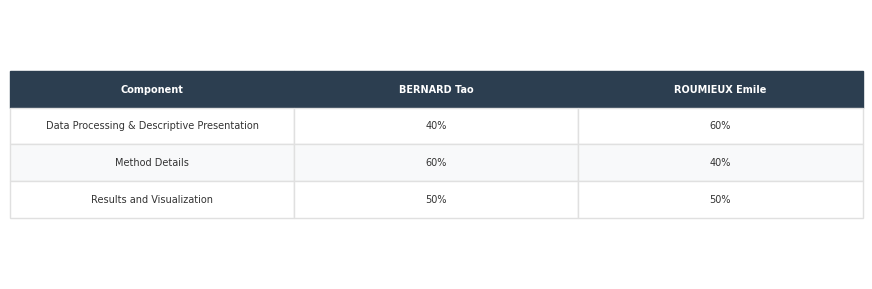

# **ANNEXES**

**Annexe 3. Data Processing and Exploratory Analysis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import GradientBoostingClassifier

Saving bank_dataset.csv to bank_dataset (1).csv


/tmp/ipykernel_4925/4244084399.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='deposit', y='balance', data=data, palette='Pastel1')


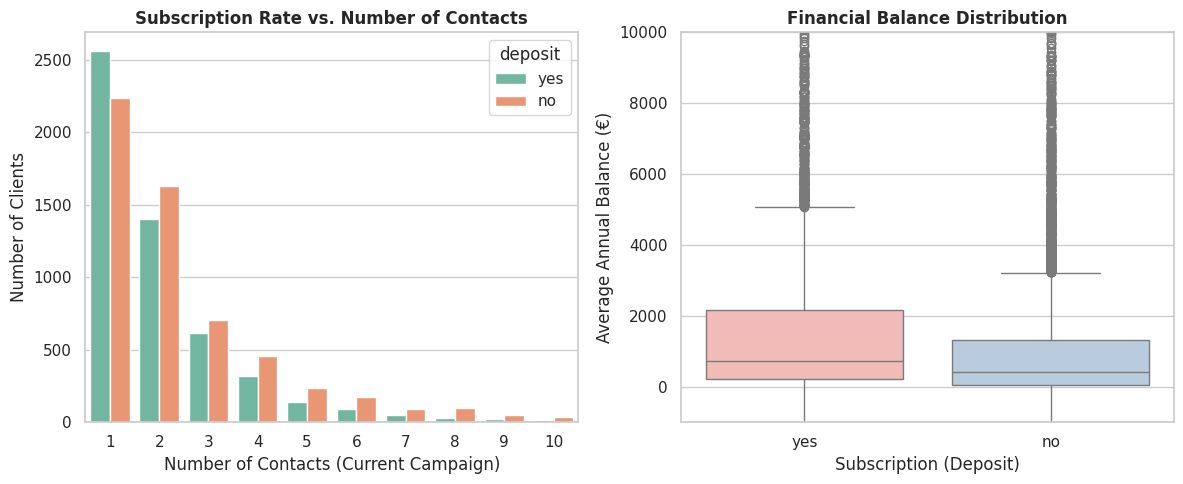

Starting data processing pipeline...
✅ Data Processing completed successfully!


In [ ]:
import pandas as pd
import io
from google.colab import files
uploaded = files.upload()
# Get the actual filename from the uploaded dictionary
uploaded_file_name = list(uploaded.keys())[0]
data = pd.read_csv(io.BytesIO(uploaded[uploaded_file_name]), sep=',')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot 1: Marketing Fatigue (Saturation)
plt.subplot(1, 2, 1)
campaign_data = data[data['campaign'] <= 10]
sns.countplot(x='campaign', hue='deposit', data=campaign_data, palette='Set2')
plt.title('Subscription Rate vs. Number of Contacts', fontweight='bold')
plt.xlabel('Number of Contacts (Current Campaign)')
plt.ylabel('Number of Clients')

# Plot 2: Financial Balance Impact
plt.subplot(1, 2, 2)
sns.boxplot(x='deposit', y='balance', data=data, palette='Pastel1')
plt.ylim(-1000, 10000)
plt.title('Financial Balance Distribution', fontweight='bold')
plt.xlabel('Subscription (Deposit)')
plt.ylabel('Average Annual Balance (€)')

plt.tight_layout()
plt.show()

print("Starting data processing pipeline...")

# A. Handle extreme values (Outliers)
p99 = data['balance'].quantile(0.99)
data['balance'] = np.clip(data['balance'], None, p99)

# B. Drop noisy or irrelevant columns
data_clean = data.drop(columns=['day', 'pdays', 'previous'])

# C. Target variable encoding (yes=1, no=0)
data_clean['deposit'] = data_clean['deposit'].map({'yes': 1, 'no': 0})


print("✅ Data Processing completed successfully!")

In [1]:
deposit = 'deposit'
train_data, test_data = train_test_split(data_clean, test_size=0.30, random_state=42)
X_train = train_data.drop(columns=[deposit])
y_train = train_data[deposit]

X_test = test_data.drop(columns=[deposit])
y_test = test_data[deposit]

NameError: name 'train_test_split' is not defined

In [ ]:
# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns

# Apply one-hot encoding
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial for consistency between train and test
# This ensures that both dataframes have the same columns, adding missing ones as all zeros
train_cols = X_train_encoded.columns
test_cols = X_test_encoded.columns


**Annexe 4. Method Details**

A. Logistic Regression

In [ ]:

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_encoded[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0

X_test_encoded = X_test_encoded[train_cols] # Ensure order is the same


In [ ]:
# Identify numerical columns (those not already encoded)
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_encoded[numerical_cols])

print("X_train_scaled head:")
display(X_train_scaled.head())
print("\nX_test_scaled head:")
display(X_test_scaled.head())

X_train_scaled head:


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
7968,1.330255,-0.208467,-0.784541,2.608028,-0.550775,-0.472571,-0.375762,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1456,-0.610758,-0.219185,-0.309441,0.980204,-0.550775,-0.472571,-0.375762,False,False,False,...,False,False,False,False,False,False,False,False,False,True
361,-0.020015,-0.583616,-1.734742,0.315195,2.387568,-0.472571,-0.375762,True,False,False,...,True,False,False,False,False,False,False,False,False,True
812,0.401944,1.276695,0.284434,0.387479,1.652982,-0.472571,-0.375762,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1092,-1.117109,1.298561,1.472184,1.153684,-0.550775,-0.472571,-0.375762,False,False,False,...,False,False,False,False,False,False,False,False,False,True



X_test_scaled head:


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
5527,2.005389,-0.296787,-1.259642,-0.543533,-0.550775,-0.472571,-0.375762,False,False,False,...,True,False,False,False,False,False,False,False,False,True
4541,-0.273191,0.081792,0.046884,2.755487,2.387568,-0.472571,-0.375762,True,False,False,...,False,True,False,False,False,False,False,False,False,True
1964,-0.526366,1.512075,-0.190666,0.248695,-0.550775,2.319118,0.092622,True,False,False,...,False,False,False,True,False,False,False,False,False,False
5007,0.486336,2.912346,-0.903316,1.197054,-0.183482,-0.472571,-0.375762,True,False,False,...,False,False,False,False,False,False,False,False,False,True
8928,-0.526366,0.015765,-0.428216,-0.826884,0.183811,-0.472571,-0.375762,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [ ]:
# Fit Logistic Regression model on scaled data
log_reg_scaled = LogisticRegression(max_iter=1000) # Increased max_iter to potentially help with convergence
log_reg_scaled.fit(X_train_scaled, y_train)

# Predict on scaled test data
y_pred_reg = log_reg_scaled.predict(X_test_scaled)

# Evaluate the model
print("Accuracy after scaling:", accuracy_score(y_test, y_pred_reg))
print("\nClassification Report after scaling:")
print(classification_report(y_test, y_pred_reg))

Accuracy after scaling: 0.8196476560167214

Classification Report after scaling:
              precision    recall  f1-score   support

          no       0.81      0.85      0.83      1742
         yes       0.83      0.79      0.81      1607

    accuracy                           0.82      3349
   macro avg       0.82      0.82      0.82      3349
weighted avg       0.82      0.82      0.82      3349



In [ ]:
# Extract coefficients from the scaled logistic regression model
log_reg_scaled_coef = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': log_reg_scaled.coef_[0]
})

# Sort by absolute coefficient value to see the most influential features
log_reg_scaled_coef_sorted = log_reg_scaled_coef.reindex(log_reg_scaled_coef['Coefficient'].abs().sort_values(ascending=False).index)

print("=== Logistic Regression Coefficients (Scaled Data) ===")
display(log_reg_scaled_coef_sorted)


=== Logistic Regression Coefficients (Scaled Data) ===


,Feature,Coefficient
40,poutcome_success,2.038726
3,duration,1.901575
34,month_mar,1.774250
27,contact_unknown,-1.522377
29,month_dec,1.167673
31,month_jan,-1.150183
38,month_sep,1.052026
37,month_oct,1.043900
36,month_nov,-0.986736
32,month_jul,-0.882802


B. LASSO Regularization

In [ ]:


potential_numerical_cols = ['age', 'balance', 'duration', 'campaign']
cols_to_scale = [c for c in potential_numerical_cols if c in X_train_encoded.columns]

scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train_encoded[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test_encoded[cols_to_scale])

# OPTIMAL LASSO TRAINING (Grid Search + Cross Validation)
lasso_model = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty='l1',
    solver='liblinear',
    scoring='accuracy',
    random_state=2026
)
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

print("=== OPTIMAL LASSO MODEL PERFORMANCE ===")
print(f"Optimal Regularization Strength (C): {lasso_model.C_[0]:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lasso):.4f}")
print("\n=== LASSO VARIABLE SELECTION ANALYSIS ===")

# 1. Create the base coefficients DataFrame
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lasso_model.coef_[0]
})

# 2. Filter out zero coefficients (variables dropped by LASSO)
selected_features = coefficients[coefficients['Coefficient'] != 0].copy()

selected_features['Abs_Coefficient'] = selected_features['Coefficient'].abs()

selected_features_sorted = selected_features.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])


top_positive = coefficients[coefficients['Coefficient'] > 0].sort_values(by='Coefficient', ascending=False).head(5)

top_negative = coefficients[coefficients['Coefficient'] < 0].sort_values(by='Coefficient', ascending=True).head(5)



print("\n📊 TOP 5 POSITIVE DRIVERS" )
print("-" * 55)
display(top_positive)

print("\n🛑 TOP 5 NEGATIVE INHIBITORS" )
print("-" * 55)
display(top_negative)

print("\n📋 ALL ACTIVE VARIABLES (Sorted by Absolute Math Impact)")
print("-" * 55)
display(selected_features_sorted)

=== OPTIMAL LASSO MODEL PERFORMANCE ===
Optimal Regularization Strength (C): 166.8101
Test Accuracy: 0.8199

=== LASSO VARIABLE SELECTION ANALYSIS ===

📊 TOP 5 POSITIVE DRIVERS
-------------------------------------------------------


,Feature,Coefficient
40,poutcome_success,2.101092
3,duration,1.912516
34,month_mar,1.895698
29,month_dec,1.469283
38,month_sep,1.138744



🛑 TOP 5 NEGATIVE INHIBITORS
-------------------------------------------------------


,Feature,Coefficient
27,contact_unknown,-1.552245
31,month_jan,-1.183617
36,month_nov,-0.975829
32,month_jul,-0.874055
28,month_aug,-0.808445



📋 ALL ACTIVE VARIABLES (Sorted by Absolute Math Impact)
-------------------------------------------------------


,Feature,Coefficient
40,poutcome_success,2.101092
3,duration,1.912516
34,month_mar,1.895698
27,contact_unknown,-1.552245
29,month_dec,1.469283
31,month_jan,-1.183617
38,month_sep,1.138744
37,month_oct,1.101603
36,month_nov,-0.975829
32,month_jul,-0.874055


In [ ]:

# 1. Générer les prédictions
y_pred_lasso = lasso_model.predict(X_test_scaled)

# 2. Afficher le rapport de classification
print("\n=== CLASSIFICATION REPORT (LASSO) ===")
print(classification_report(y_test, y_pred_lasso))

# 3. Afficher la matrice de confusion
print("\n=== CONFUSION MATRIX (LASSO) ===")
print(confusion_matrix(y_test, y_pred_lasso))


=== CLASSIFICATION REPORT (LASSO) ===
              precision    recall  f1-score   support

          no       0.81      0.85      0.83      1742
         yes       0.83      0.79      0.81      1607

    accuracy                           0.82      3349
   macro avg       0.82      0.82      0.82      3349
weighted avg       0.82      0.82      0.82      3349


=== CONFUSION MATRIX (LASSO) ===
[[1479  263]
 [ 340 1267]]


C. Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100,
                                  max_depth=10,
                                max_features='sqrt',  # default for classification
                                random_state=42)
rf_model.fit(X_train_encoded, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_encoded)

# Evaluation
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

0.8330845028366677
              precision    recall  f1-score   support

          no       0.86      0.81      0.83      1742
         yes       0.81      0.86      0.83      1607

    accuracy                           0.83      3349
   macro avg       0.83      0.83      0.83      3349
weighted avg       0.83      0.83      0.83      3349

[[1414  328]
 [ 231 1376]]


In [ ]:

# Define and train rf_model (copied from VyYURdkm-Zxf to ensure it's available)
rf_model = RandomForestClassifier(n_estimators=100,
                                  max_depth=10,
                                  max_features='sqrt',
                                  random_state=42)
rf_model.fit(X_train_encoded, y_train)


# Get mean absolute SHAP values for class 1 (yes)
# Correctly index for class 1 across all samples and features
shap_abs_mean = np.abs(shap_values[:, :, 1]).mean(axis=0)

# Create a DataFrame to display feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X_test_encoded.columns,
    'Mean_Abs_SHAP': shap_abs_mean
}).sort_values(by='Mean_Abs_SHAP', ascending=False)

print('\nTop features by Mean Absolute SHAP value for Class 1 (Yes):')
display(feature_importance_df)


Top features by Mean Absolute SHAP value for Class 1 (Yes):


,Feature,Mean_Abs_SHAP
3,duration,0.152876
27,contact_unknown,0.043530
24,housing_yes,0.036785
40,poutcome_success,0.031016
5,pdays,0.029046
1,balance,0.018600
35,month_may,0.017643
41,poutcome_unknown,0.017348
0,age,0.015615
6,previous,0.014111


D. Gradient Boosting

In [ ]:
gbm_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gbm_model.fit(X_train_encoded, y_train)

# Predicted class
y_pred_gbm = gbm_model.predict(X_test_encoded)

# Predicted probability (uses sigmoid internally)
y_proba_gbm = gbm_model.predict_proba(X_test_encoded)[:, 1]

# Evaluation
print(accuracy_score(y_test, y_pred_gbm))
print(classification_report(y_test, y_pred_gbm))
print(confusion_matrix(y_test, y_pred_gbm))

0.8408480143326366
              precision    recall  f1-score   support

          no       0.86      0.83      0.84      1742
         yes       0.82      0.85      0.84      1607

    accuracy                           0.84      3349
   macro avg       0.84      0.84      0.84      3349
weighted avg       0.84      0.84      0.84      3349

[[1448  294]
 [ 239 1368]]


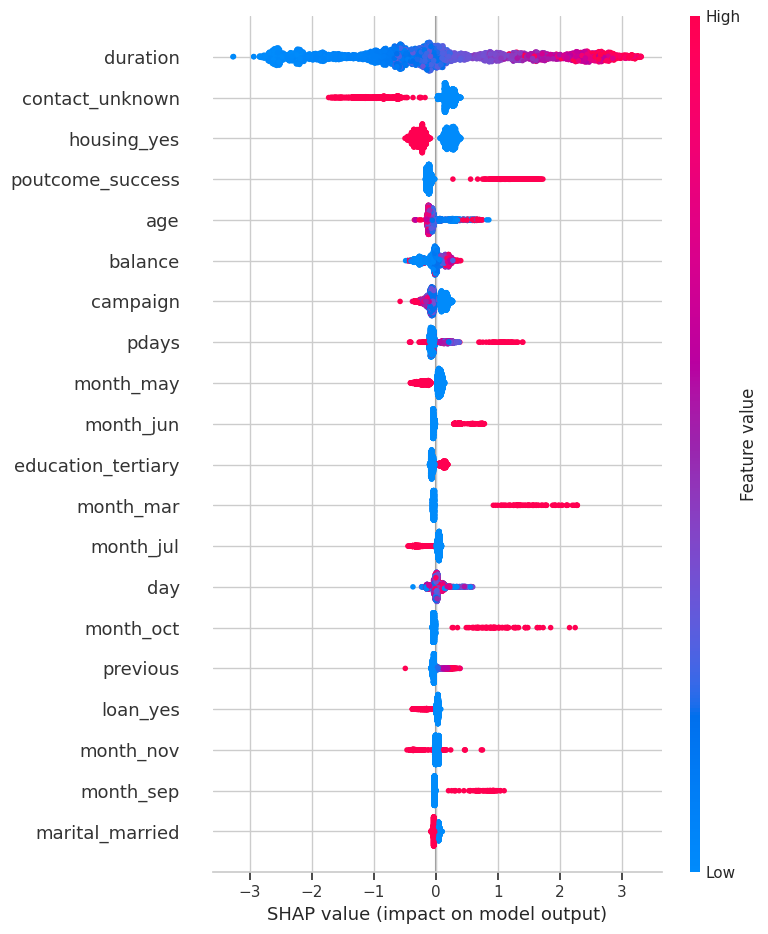

In [ ]:

explainer = shap.TreeExplainer(gbm_model)
shap_values = explainer.shap_values(X_test_encoded)
shap.summary_plot(shap_values, X_test_encoded)
